# Testing DD pulse sequences in qiskit

Key Libraries used : 
Qiskit


### 1. Apply DD on GHZ state preparation circuit

In [11]:
## Import Statements
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.transpiler import CouplingMap


from qiskit.circuit.library import XGate, YGate


from qiskit.transpiler import PassManager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,ASAPScheduleAnalysis,
    PadDynamicalDecoupling,
)
 
from qiskit.visualization.timeline import draw, IQXStandard
from qiskit_ibm_runtime import QiskitRuntimeService


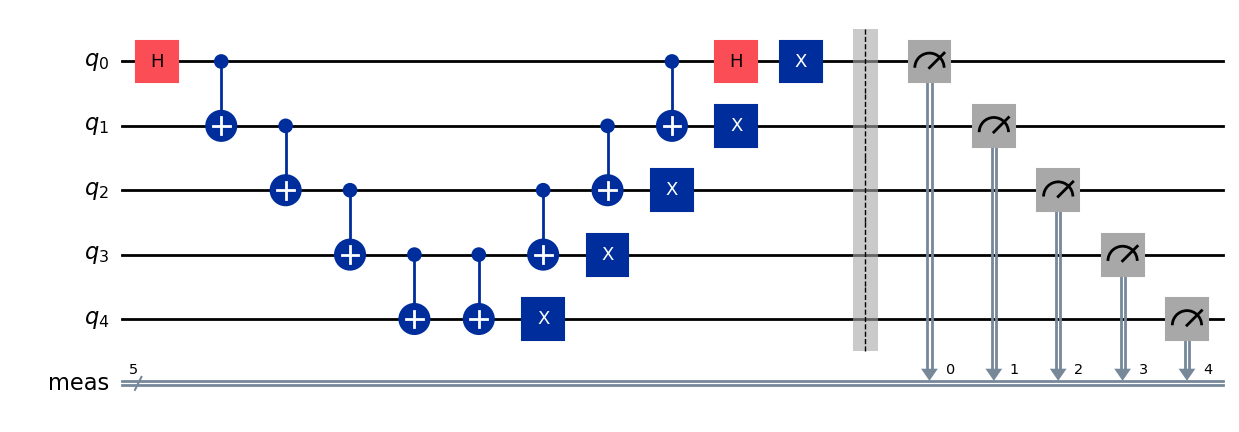

In [12]:
## Circuit prep function
def prepare_ghz(n_qubits:int):
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.x(range(n_qubits))
    circuit.measure_all()

    return circuit


qc = prepare_ghz(5)
qc_no_measure = prepare_ghz(5).remove_final_measurements(inplace=False)


qc.draw("mpl")
# qc_no_measure.draw("mpl")


In [17]:
service = QiskitRuntimeService(name='qamp-2025')
torino = service.backend('ibm_torino')
torino


management.get:WARNING:2025-11-15 20:36:50,216: Loading saved account: qamp-2025


<IBMBackend('ibm_torino')>

In [19]:
dir(torino)

['__abstractmethods__',
 '__call__',
 '__class__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_api_client',
 '_calibration_id',
 '_configuration',
 '_convert_to_target',
 '_coupling_map',
 '_default_options',
 '_instance',
 '_options',
 '_properties',
 '_provider',
 '_service',
 '_target',
 'backend_version',
 'calibration_id',
 'check_faulty',
 'configuration',
 'coupling_map',
 'description',
 'dt',
 'dtm',
 'get_translation_stage_plugin',
 'id_warning_issued',
 'instruction_durations',
 'instructions',
 'max_circuits',
 'meas_map',
 'name',
 'num_qubits',
 'online_date',
 'operation_names',
 'oper

In [ ]:
print(torino.backend_version)
print(torino.calibration_id)
    

1.0.105
None
None


In [9]:
print(target.operations)
print(target.operation_names)
print(target.operation_from_name('id'))
print(target.build_coupling_map())

[<class 'qiskit.circuit.controlflow.for_loop.ForLoopOp'>, Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), <class 'qiskit.circuit.controlflow.if_else.IfElseOp'>, Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]), Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]), Delay(duration=t[unit=dt]), <class 'qiskit.circuit.controlflow.switch_case.SwitchCaseOp'>, Instruction(name='ecr', num_qubits=2, num_clbits=0, params=[])]
dict_keys(['for_loop', 'x', 'if_else', 'rz', 'measure', 'id', 'reset', 'sx', 'delay', 'switch_case', 'ecr'])
Instruction(name='id', num_qubits=1, num_clbits=0, params=[])
[[1, 0], [2, 1], [3, 2], [4, 3], [4, 5], [4, 15], [6, 5], [6, 7], [7, 8], [8, 9], [10, 9], [10, 11], [11, 12], [12, 17], [13, 12], [14, 0], [14, 18], [15, 22], [16,

In [10]:
print(target._instruction_durations)

None


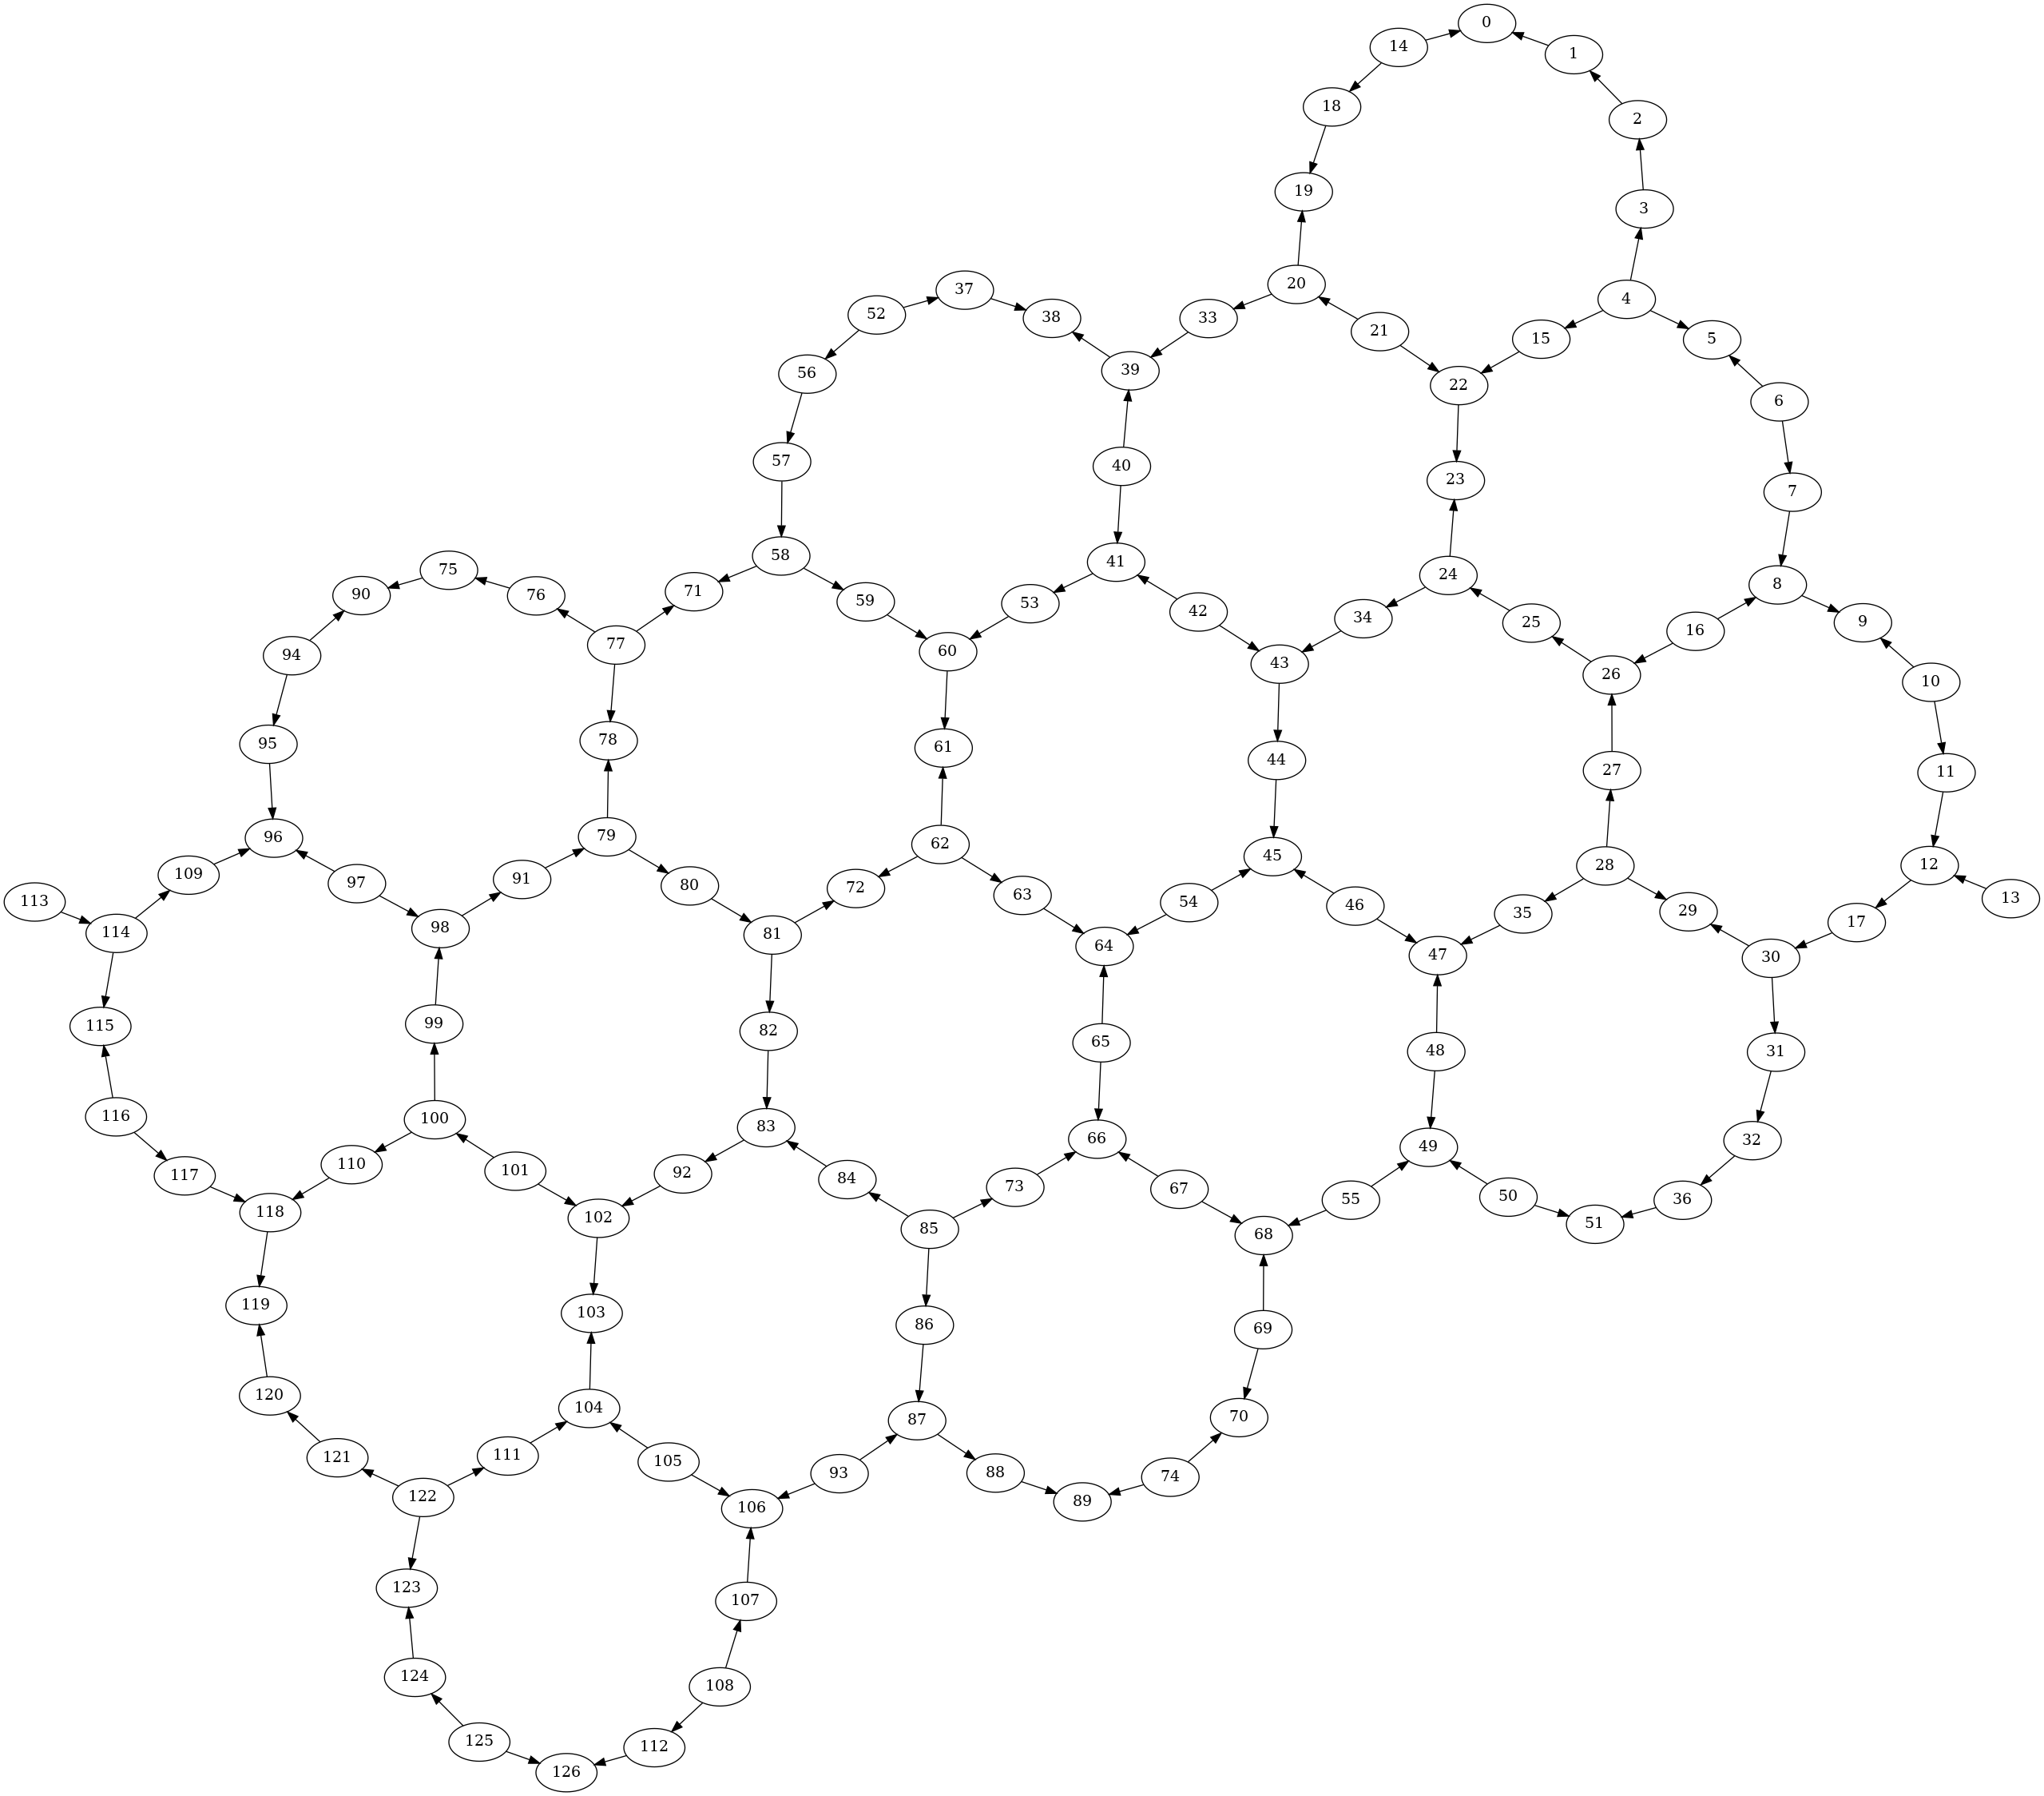

In [70]:
fbrisbane_cm = CouplingMap(target.build_coupling_map())
fbrisbane_cm.draw()

In [71]:
pm_lvl3 = generate_preset_pass_manager(optimization_level=3, seed_transpiler=42, backend=fbrisbane)

transpiled_circuit = pm_lvl3.run(qc)

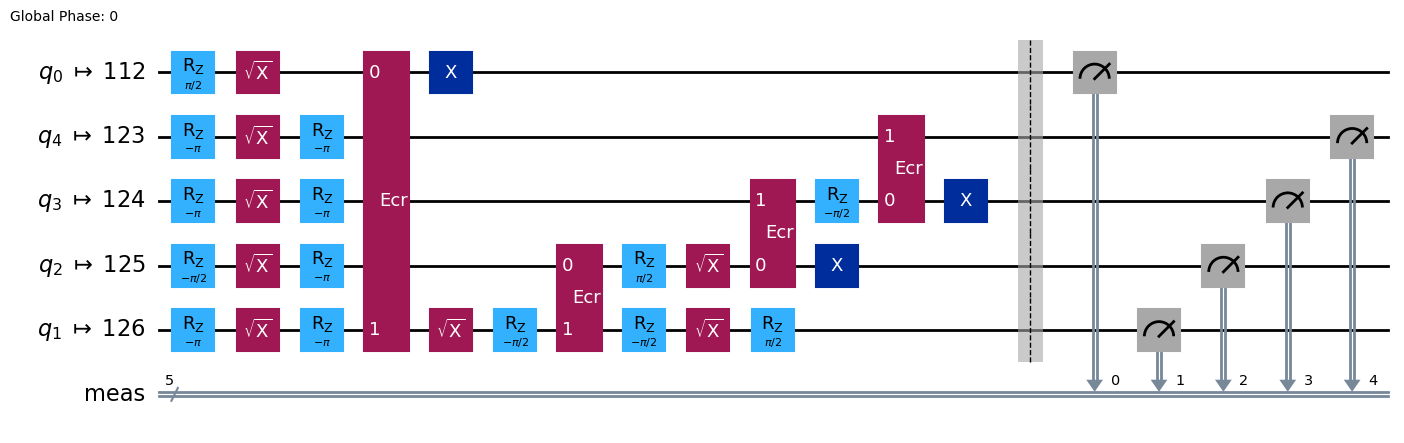

In [72]:
transpiled_circuit.draw("mpl")

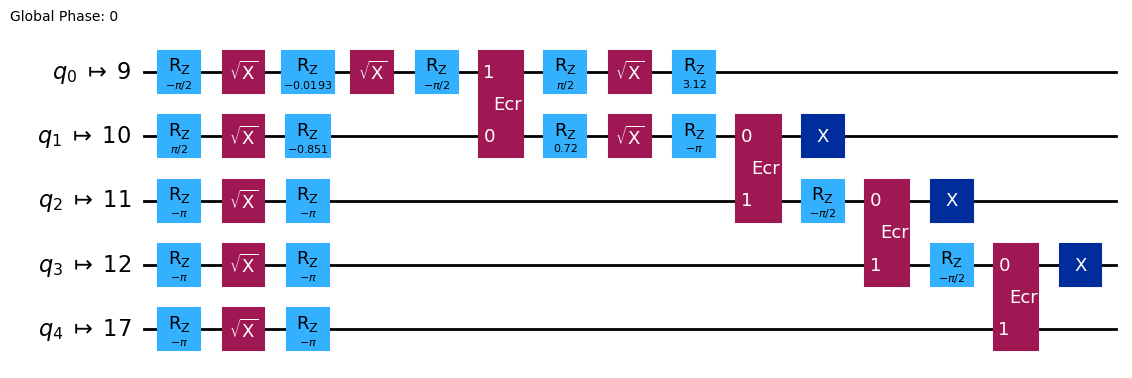

In [73]:
transpiled_circuit_no_measure = pm_lvl3.run(qc_no_measure)
transpiled_circuit_no_measure.draw("mpl")

In [ ]:
## Writing a CPMG DD pass using ALAP analysis
 
X = XGate()
 
dd_sequence = [X, X]

dd_alap_pm = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        PadDynamicalDecoupling(target=target, dd_sequence=dd_sequence),
    ]
)

dd_transpiled_circuit_no_measure1 = dd_alap_pm.run(transpiled_circuit_no_measure)

# dd_transpiled_circuit_no_measure.draw("mpl")

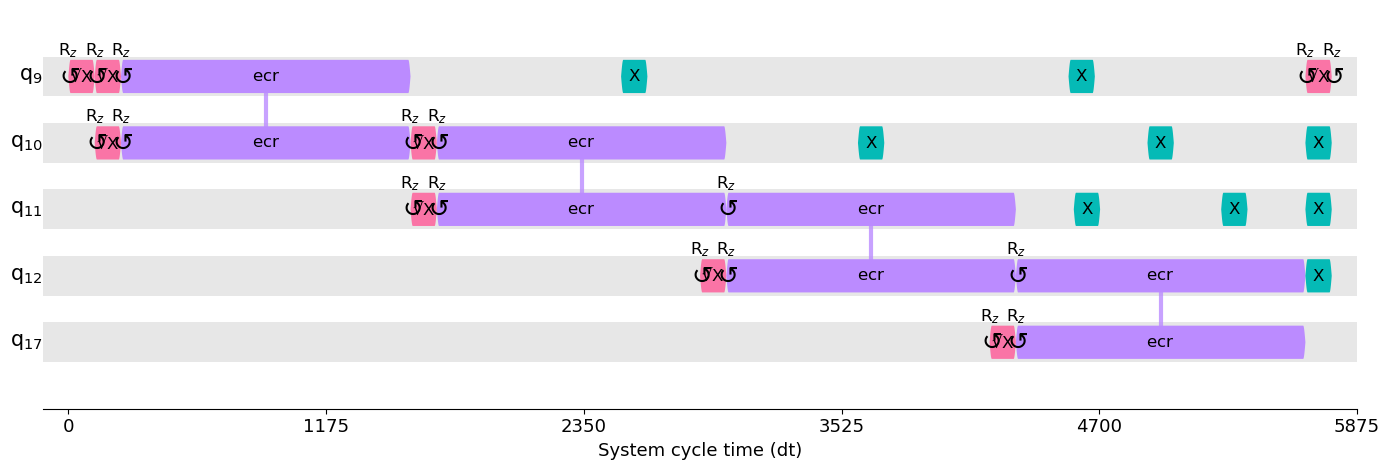

In [ ]:
from qiskit.visualization import timeline_drawer
 
timeline_drawer(dd_transpiled_circuit_no_measure1, idle_wires=False, target=target)

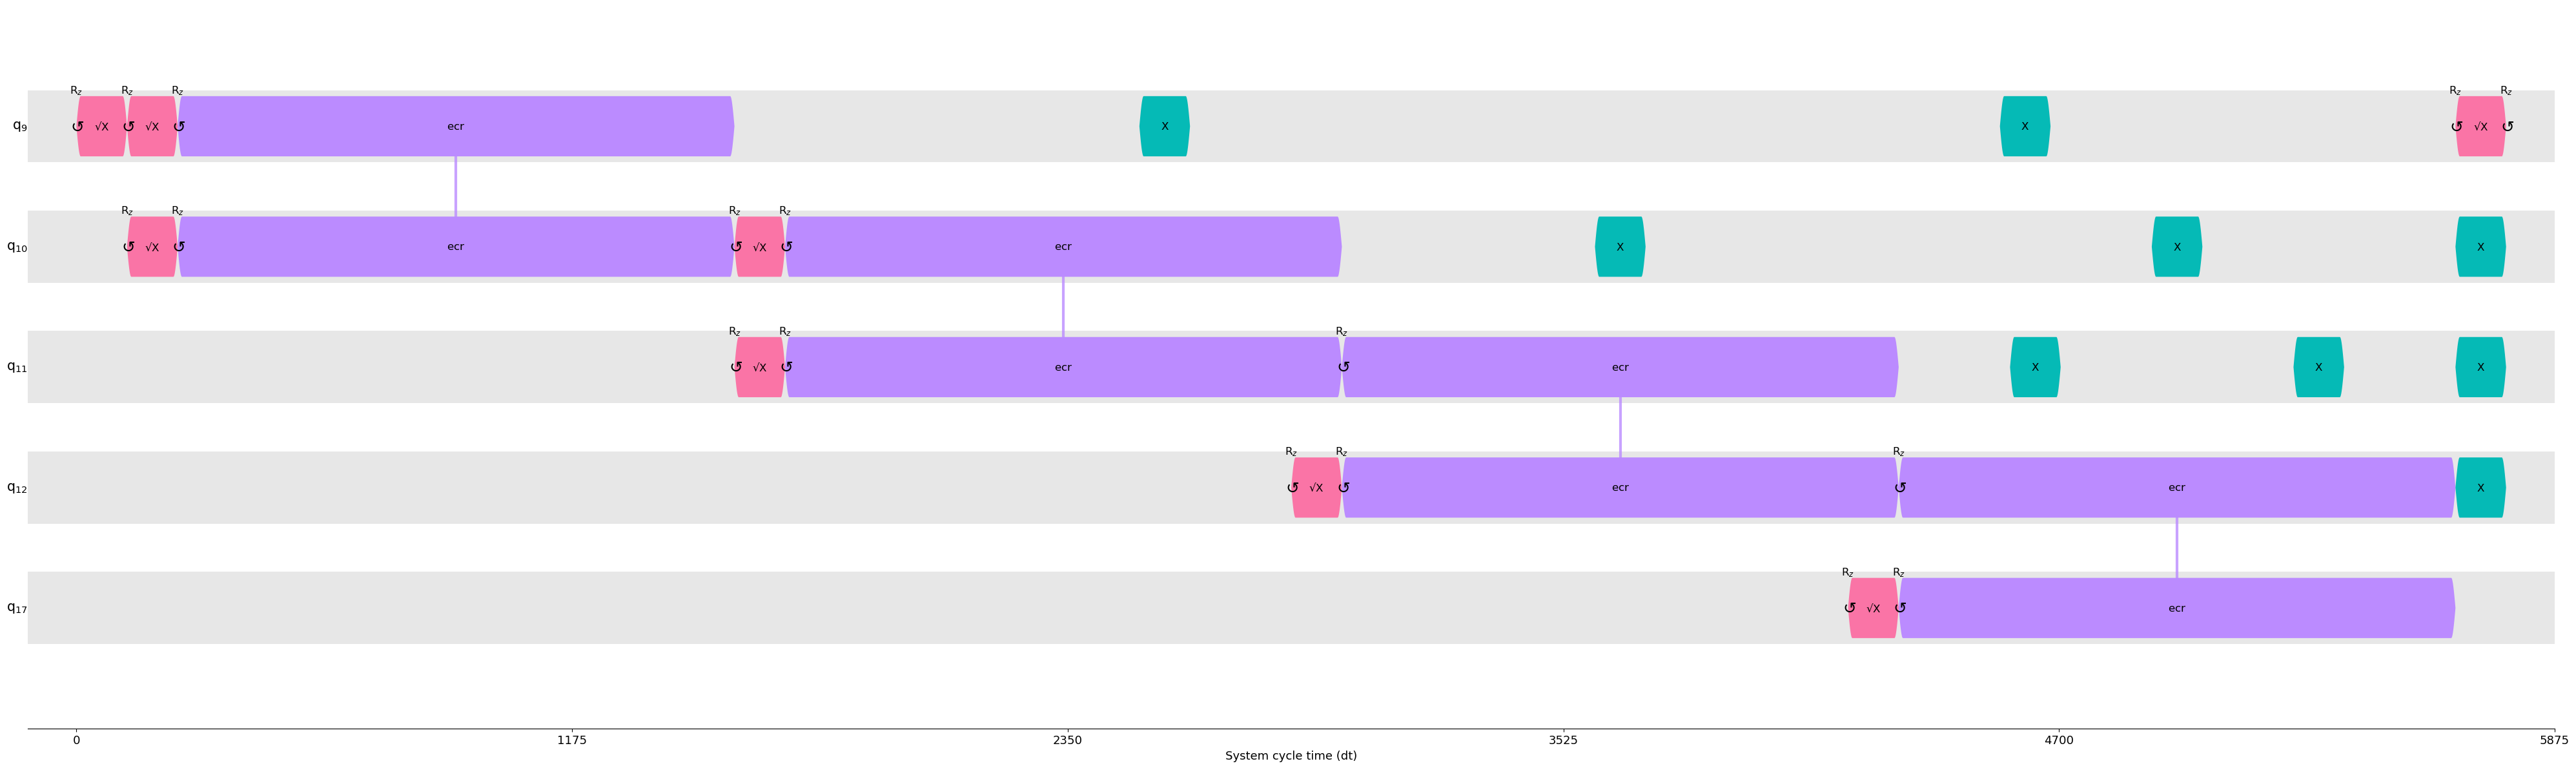

In [ ]:
my_style = {
    'formatter.general.fig_width': 40,
    'formatter.general.fig_unit_height': 2,
}

draw(dd_transpiled_circuit_no_measure1, target=target, style=IQXStandard(**my_style), show_idle=False, show_delays=False)

In [ ]:
## Writing a CPMG DD pass using ASAP analysis


